## We are practicing ANN

In [1]:
%pip install --upgrade tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# we are practicing deep learning - neural networks


# We will implement ANN - Artificial Neural Network

In [2]:
import tensorflow as tf
print(tf.__version__)

c:\Users\sahil\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


2.21.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [5]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Separating features and target 

In [6]:
X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [7]:
X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [8]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

# Feature Engineering

### Encoding Categorical Columns 

In [9]:
categorical_cols = ['Geography', 'Gender']

In [10]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = encoder.fit_transform(dataset[categorical_cols])

In [11]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=dataset.index
)

In [12]:
encoded_df.head()

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0


In [13]:
categorical_cols = [ 'Geography', 'Gender']

# Dropping original categorical columns
X_dropped = X.drop(columns=categorical_cols)

# Concatenate one-hot encoded columns
X = pd.concat([X_dropped, encoded_df], axis=1)

In [14]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0,1.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0,1.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0,1.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0,1.0,0.0


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
X_train

array([[ 1.058568  ,  1.71508648,  0.68472287, ..., -0.57773517,
        -0.90750738,  0.90750738],
       [ 0.91362605, -0.65993547, -0.6962018 , ..., -0.57773517,
        -0.90750738,  0.90750738],
       [ 1.07927399, -0.18493108, -1.73189531, ..., -0.57773517,
         1.10191942, -1.10191942],
       ...,
       [ 0.16821031, -0.18493108,  1.3751852 , ..., -0.57773517,
         1.10191942, -1.10191942],
       [ 0.37527024, -0.37493284,  1.02995403, ...,  1.73089688,
        -0.90750738,  0.90750738],
       [ 1.56586482,  1.14508121,  0.68472287, ...,  1.73089688,
        -0.90750738,  0.90750738]], shape=(8000, 13))

In [20]:
X_test

array([[-0.68073539, -0.27993196,  0.68472287, ..., -0.57773517,
        -0.90750738,  0.90750738],
       [-1.30191518, -0.5649346 , -0.35097064, ..., -0.57773517,
        -0.90750738,  0.90750738],
       [-0.97061929,  0.10007155, -0.35097064, ...,  1.73089688,
         1.10191942, -1.10191942],
       ...,
       [-1.39509214,  0.7650777 ,  1.3751852 , ..., -0.57773517,
         1.10191942, -1.10191942],
       [ 0.39597623,  0.00507067,  0.68472287, ..., -0.57773517,
        -0.90750738,  0.90750738],
       [ 1.02750901, -0.5649346 , -1.04143297, ..., -0.57773517,
        -0.90750738,  0.90750738]], shape=(2000, 13))

In [21]:
y_train

2151    1
8392    1
5006    0
4117    0
7182    0
       ..
4555    1
4644    0
8942    0
2935    0
6206    0
Name: Exited, Length: 8000, dtype: int64

In [22]:
X_train.shape

(8000, 13)

In [23]:
X_test.shape

(2000, 13)

## Part 2 - Let's create the ANN

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU , PReLU , ELU , ReLU
from tensorflow.keras.layers import Dropout


In [25]:
### initializing the ANN

classifier = Sequential()

In [26]:
### Adding the Input layer

classifier.add(Dense(units = 13 , activation= 'relu'))

### Adding the First Layer 

classifier.add(Dense(units = 5 , activation='relu'))

### Adding the second Hidden layer 

classifier.add(Dense(units = 8 , activation='relu'))

### Adding the output layer

classifier.add(Dense(units = 1 , activation='sigmoid'))

In [29]:
classifier.compile(optimizer = opt , loss = 'binary_crossentropy' , metrics = ["accuracy"])

In [38]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [41]:

model_history = classifier.fit(
    X_train,
    y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8655 - loss: 0.3229 - val_accuracy: 0.8550 - val_loss: 0.3610
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.3275 - val_accuracy: 0.8538 - val_loss: 0.3765
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - loss: 0.3219 - val_accuracy: 0.8440 - val_loss: 0.3645
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8623 - loss: 0.3212 - val_accuracy: 0.8455 - val_loss: 0.3600
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8655 - loss: 0.3223 - val_accuracy: 0.8550 - val_loss: 0.3682
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3244 - val_accuracy: 0.8512 - val_loss: 0.3706
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8658 - loss: 0.3200 - val_accuracy: 0.8508 - val_loss: 0.3569
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8664 - loss: 0.3216 - val_accu

In [42]:
print(model_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [43]:
model_history.history['accuracy']

[0.8654599785804749,
 0.8604217171669006,
 0.8639671802520752,
 0.8622877597808838,
 0.8654599785804749,
 0.8645269870758057,
 0.8658331632614136,
 0.866392970085144,
 0.8635939359664917,
 0.8656466007232666,
 0.8650867938995361,
 0.8688188195228577]

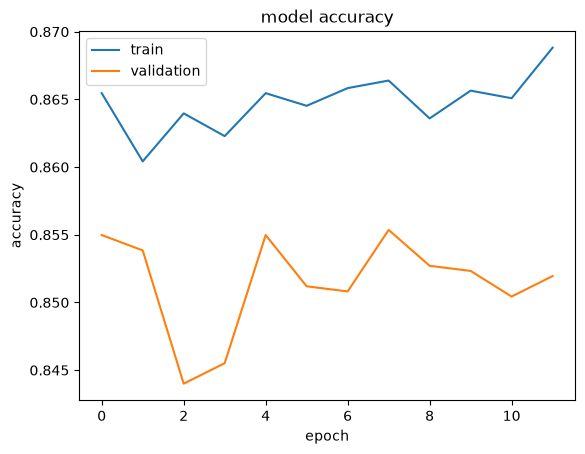

In [44]:

# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

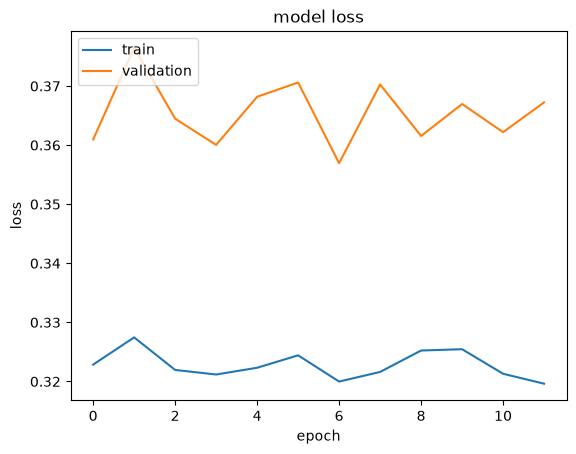

In [45]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [47]:
## Let's predict and evaluate the model

y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [48]:
y_pred

array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [False]], shape=(2000, 1))

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.85


In [51]:
## Evaluating with confusion matrix 

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

In [52]:
cm

array([[1499,   94],
       [ 206,  201]])

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.68      0.49      0.57       407

    accuracy                           0.85      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000

